In [1]:
%cd "c:\Users\Tuan Kiet\Desktop\Workspace\VLSP_2025_SIGMA"

c:\Users\Tuan Kiet\Desktop\Workspace\VLSP_2025_SIGMA


In [2]:
from src.services import get_service

service = get_service()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


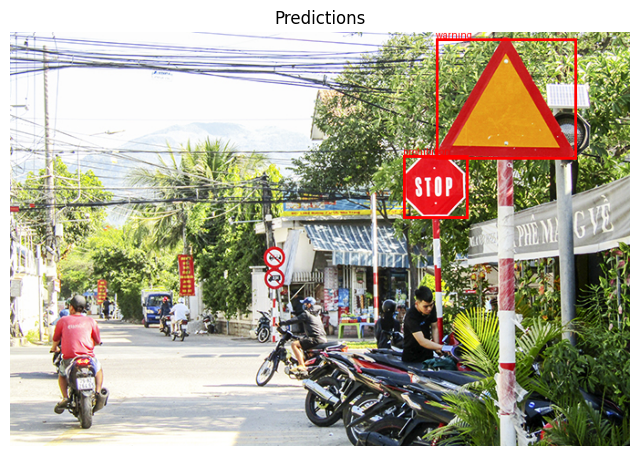

In [3]:
from src.utils.crop_utils import plot_prediction_boxes
predictions = service.detector.detect(
    image=r"data\train_data\train_images\train_images\train_1_1.jpg",
    top_k=5,
    min_area_ratio=1e-2
)

plot_prediction_boxes(
    image=r"data\train_data\train_images\train_images\train_1_1.jpg",
    predictions=predictions
)

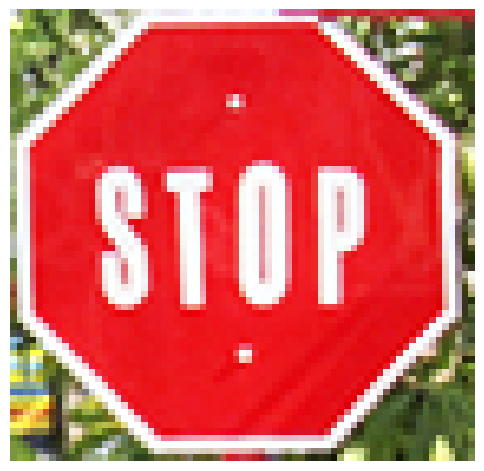

In [4]:
from src.utils.crop_utils import crop_item, show_image

cropped = crop_item(r"data\train_data\train_images\train_images\train_1_1.jpg", prediction=predictions[1])
show_image(cropped)

In [5]:
image_retrieval_results = service.image_retriever.search(cropped, top_k=10)[:2]
image_retrieval_results

  0%|          | 0/1 [00:00<?, ?it/s]

[{'filename': 'image292.jpg',
  'metadata': {'law_id': 'QCVN 41:2024/BGTVT',
   'law_title': 'QUY CHUẨN KỸ THUẬT QUỐC GIA VỀ BÁO HIỆU ĐƯỜNG BỘ',
   'article_id': 'D.1',
   'article_title': 'D.1 \xa0Biển số R.122 "Dừng lại"',
   'text': 'a) Để báo các xe (cơ giới và thô sơ) dừng lại, đặt biển số R.122 "Dừng lại". Đây là biển hiệu lệnh dạng đặc biệt.\nb) Biển có hiệu lực buộc các loại xe cơ giới và thô sơ kể cả xe được ưu tiên theo quy định dừng lại trước biển hoặc trước vạch ngang đường và chỉ được phép đi khi thấy các tín hiệu (do người điều khiển giao thông hoặc đèn cờ) cho phép đi. Trong trường hợp trên đường không đặt tín hiệu đèn cờ, không có người điều khiển giao thông hoặc các tín hiệu đèn không bật sáng thì người tham gia giao thông chỉ được phép đi khi trên đường không còn nguy cơ mất an toàn giao thông.\nc) Để đảm bảo quyền ưu tiên rẽ tại nơi giao nhau cho người tham gia giao thông ưu tiên, đặt trên đường không ưu tiên biển số R.122 kèm theo biển số S.506b "Hướng đường ưu tiên

In [6]:
import json
from tqdm.autonotebook import tqdm

from src.prompts import SIGN_ATTRIBUTES_EXTRACTION_PROMPT
from src.utils import extract_json_from_deepseek_response

image_descriptions = {}

for item in tqdm(image_retrieval_results):
    for image in item["metadata"]["images"]:
        response = service.gemma.generate(
            system_prompt=SIGN_ATTRIBUTES_EXTRACTION_PROMPT,
            user_prompt="",
            image_paths=[
                f"./data/processed/law_db/images/{image}"
            ]
        )
        image_descriptions[image] = extract_json_from_deepseek_response(response)

image_descriptions

  0%|          | 0/2 [00:00<?, ?it/s]

UnboundLocalError: cannot access local variable 'content' where it is not associated with a value